<a href="https://colab.research.google.com/github/YuriFla94/Processamento-de-Sinais-1/blob/main/aula-01/codigo/Tarefa1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**QUESTÃO 1**



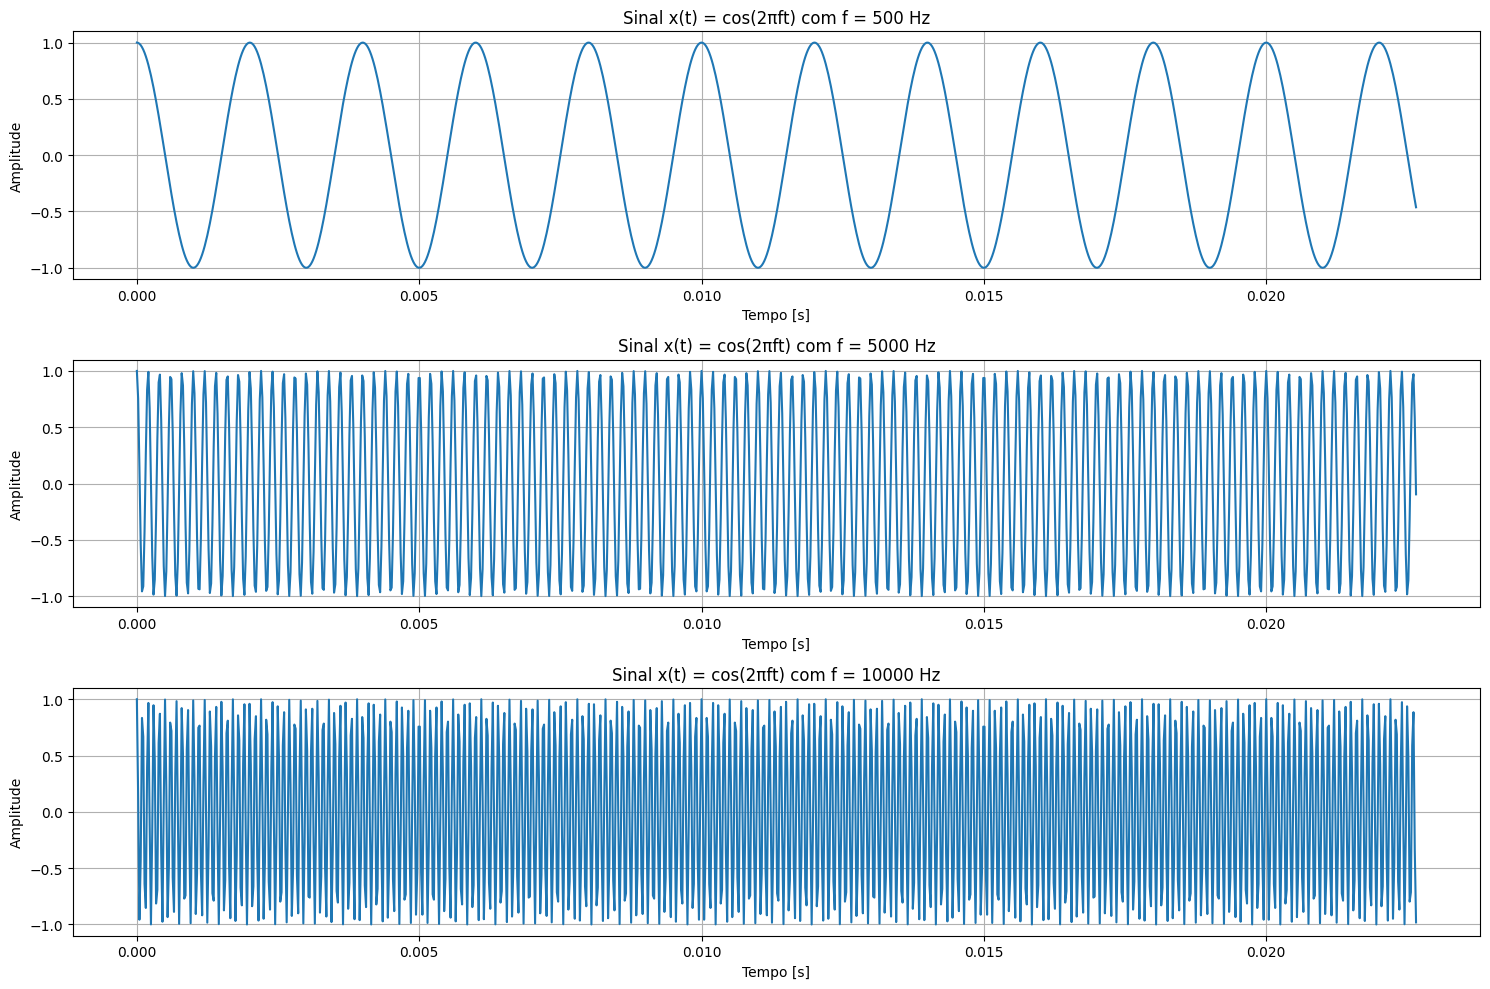

Reproduzindo sinal de 500 Hz:


Reproduzindo sinal de 5000 Hz:


Reproduzindo sinal de 10000 Hz:


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display
# Questão 1

# Parâmetros
duration = 5.0  # segundos
fs = 44100      # frequencia de amostragem (Hz)
t = np.linspace(0, duration, int(fs * duration), endpoint=False)
frequencies = [500, 5000, 10000]

signals = {}

# (a) Gerar gráficos e (b) Preparar áudio
plt.figure(figsize=(15, 10))

for i, f in enumerate(frequencies):
    x = np.cos(2 * np.pi * f * t)
    signals[f] = x

    # Plotar apenas uma pequena parte do sinal para visualização
    plt.subplot(3, 1, i+1)
    plt.plot(t[:1000], x[:1000])
    plt.title(f'Sinal x(t) = cos(2πft) com f = {f} Hz')
    plt.xlabel('Tempo [s]')
    plt.ylabel('Amplitude')
    plt.grid(True)

plt.tight_layout()
plt.show()

# (b) Tocar os sinais
for f in frequencies:
    print(f"Reproduzindo sinal de {f} Hz:")
    display(Audio(signals[f], rate=fs))

# (c) Comentários:
# 1. Domínio do Tempo: À medida que a frequência aumenta, as oscilações tornam-se mais rápidas (mais ciclos no mesmo intervalo de tempo).
# 2. Amostragem: Com fs = 44.1 kHz, a condição de Nyquist (fs > 2f) é satisfeita para todas as frequências (máx 10kHz), evitando aliasing.
# 3. Percepção Auditiva: O tom de 500Hz é grave, 5000Hz é agudo e 10000Hz é muito agudo, próximo ao limite superior da audição de muitas pessoas.

**QUESTÃO 2**

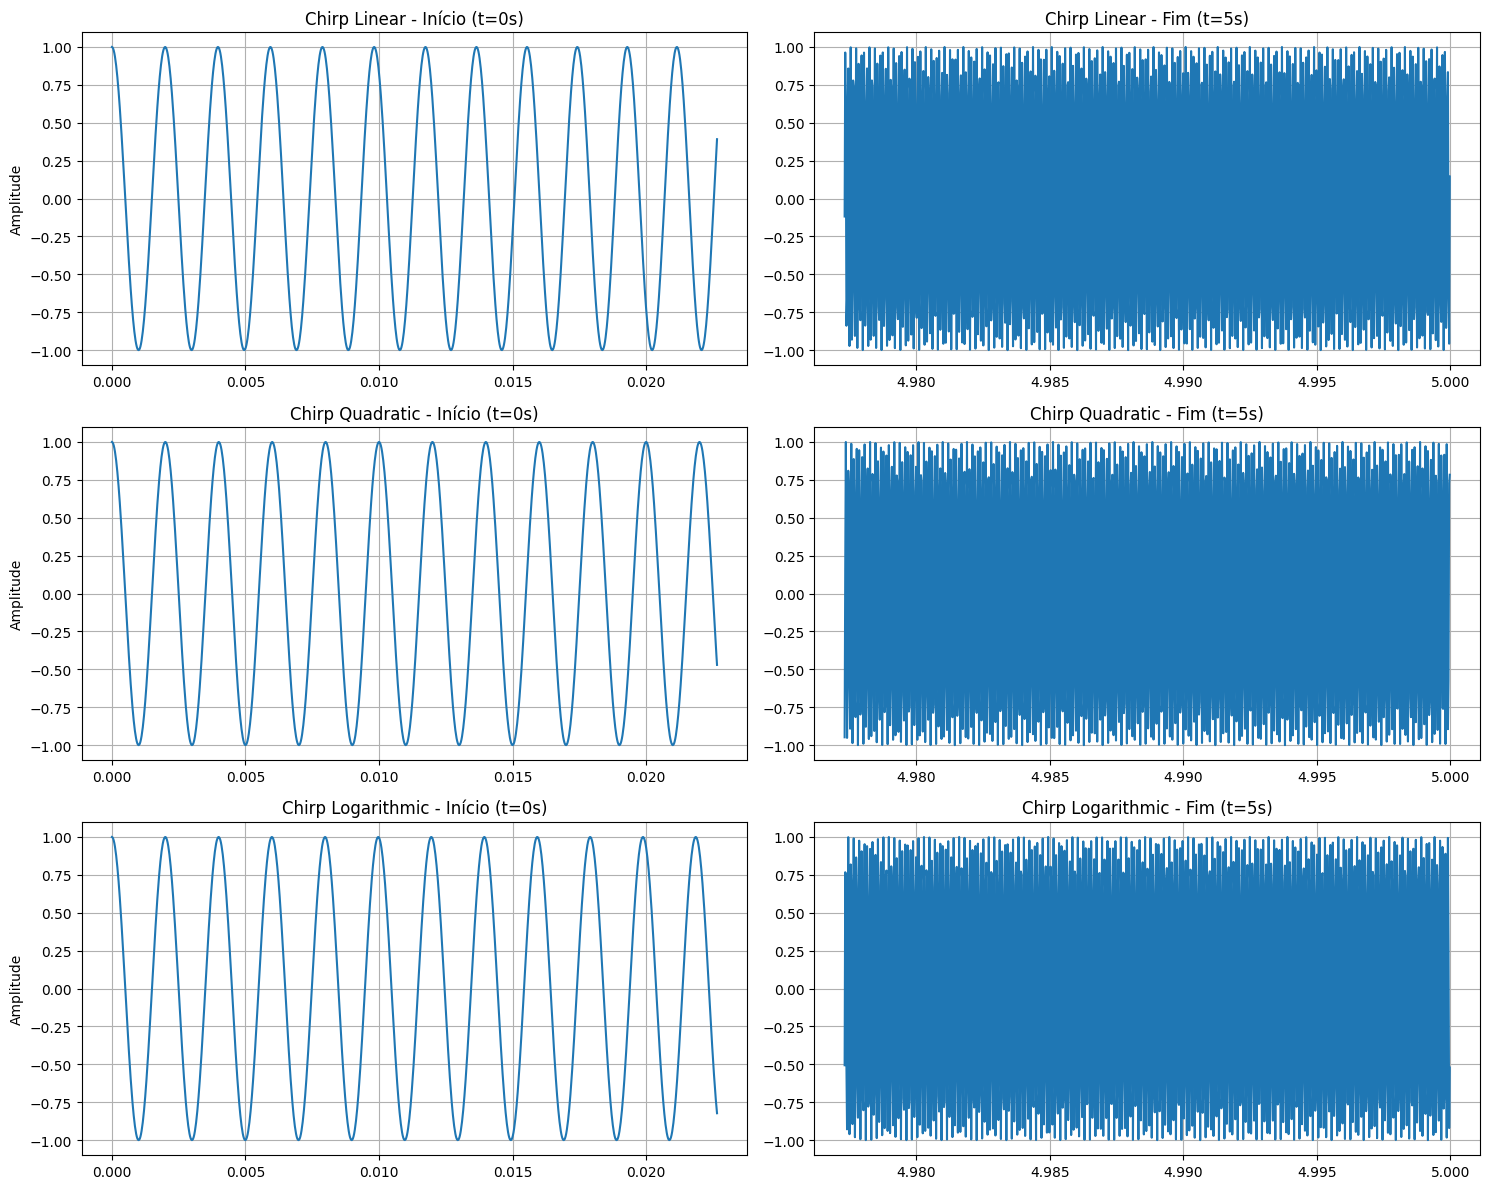

Reproduzindo Chirp Linear:


Reproduzindo Chirp Quadratic:


Reproduzindo Chirp Logarithmic:


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import chirp
from IPython.display import Audio, display

# Parâmetros
fs = 44100
duration = 5.0
t = np.linspace(0, duration, int(fs * duration), endpoint=False)
f0 = 500
f1 = 10000

methods = ['linear', 'quadratic', 'logarithmic']
chirp_signals = {}

plt.figure(figsize=(15, 12))

for i, method in enumerate(methods):
    # Geração do sinal chirp
    # Nota: Para 'logarithmic', f0 e f1 devem ser > 0
    sinal = chirp(t, f0=f0, f1=f1, t1=duration, method=method)
    chirp_signals[method] = sinal

    # Plotar o início do sinal
    plt.subplot(3, 2, 2*i + 1)
    plt.plot(t[:1000], sinal[:1000])
    plt.title(f'Chirp {method.capitalize()} - Início (t=0s)')
    plt.ylabel('Amplitude')
    plt.grid(True)

    # Plotar o fim do sinal
    plt.subplot(3, 2, 2*i + 2)
    plt.plot(t[-1000:], sinal[-1000:])
    plt.title(f'Chirp {method.capitalize()} - Fim (t=5s)')
    plt.grid(True)

plt.tight_layout()
plt.show()

# (b) Código para tocar os sinais
for method in methods:
    print(f"Reproduzindo Chirp {method.capitalize()}:")
    display(Audio(chirp_signals[method], rate=fs))

# (c) Comentários:
# 1. Varredura Linear: A percepção do aumento de tom parece constante ao longo do tempo.
# 2. Varredura Quadrática: O aumento da frequência começa devagar e acelera rapidamente no final.
# 3. Varredura Logarítmica: Soa mais natural para o ouvido humano, pois nossa percepção de oitavas é logarítmica.
# 4. Aliasing: Novamente, como f1 (10kHz) < fs/2, o sinal é representado sem distorção digital significativa.

**QUESTÃO 3**

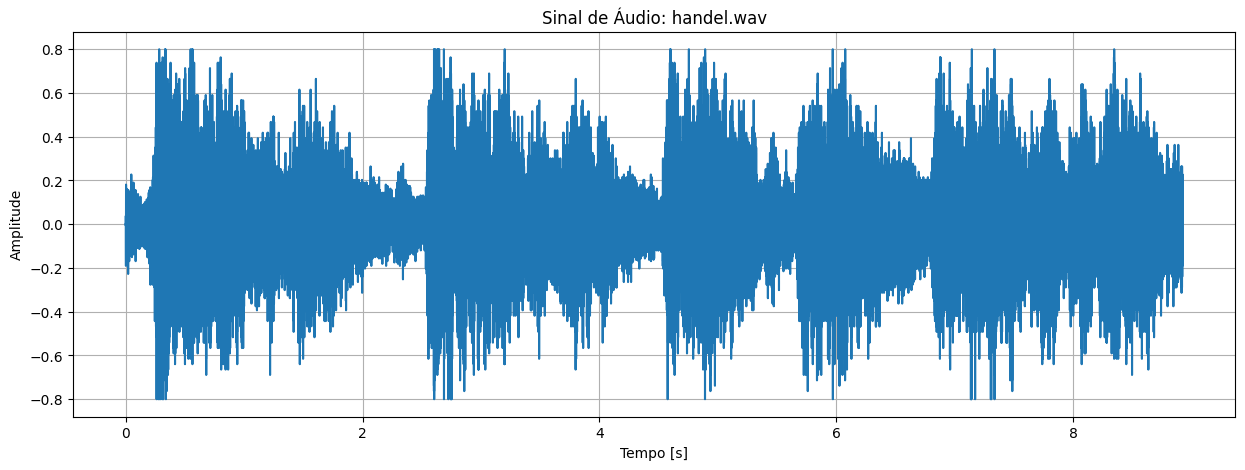

Reproduzindo com 1x a frequência original (8192 Hz):


Reproduzindo com 2x a frequência original (16384 Hz):


Reproduzindo com 4x a frequência original (32768 Hz):


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from IPython.display import Audio, display

# (a) Ler o arquivo e gerar gráfico no domínio do tempo
fs_handel, data_handel = wavfile.read('/content/handel.wav')

# Normalizar se necessário e definir eixo do tempo
if data_handel.dtype == np.int16:
    data_handel = data_handel / 32768.0

t_handel = np.linspace(0, len(data_handel) / fs_handel, len(data_handel))

plt.figure(figsize=(15, 5))
plt.plot(t_handel, data_handel)
plt.title('Sinal de Áudio: handel.wav')
plt.xlabel('Tempo [s]')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

# (b) Código para tocar os sinais com diferentes frequências de amostragem
rates = [1, 2, 4]
for multiplier in rates:
    new_fs = fs_handel * multiplier
    print(f"Reproduzindo com {multiplier}x a frequência original ({new_fs} Hz):")
    display(Audio(data_handel, rate=new_fs))

### (c) Comentários e Comparações

**Resultados Obtidos:**
- **Velocidade e Pitch:** Ao dobrar a frequência de amostragem na reprodução, o sinal é tocado na metade do tempo e todas as frequências componentes dobram (subindo uma oitava). Com 4x, o efeito é ainda mais extremo, tornando o som muito agudo e rápido.
- **Complexidade Temporal:** Diferente do cosseno puro ou do chirp, que possuem envelopes de amplitude constantes e formas de onda previsíveis, o sinal de voz/música apresenta variações bruscas de amplitude e uma estrutura muito mais rica.

**Comparação de Espectros:**
1. **Cosseno (Questão 1):** Possui um espectro de linha (impulso) em uma única frequência específica.
2. **Chirp (Questão 2):** Possui um espectro que ocupa uma banda larga (de 500Hz a 10kHz), distribuindo energia ao longo dessa faixa conforme o tipo de varredura (linear, log, etc).
3. **Handel (Questão 3):** Possui um espectro harmônico complexo. Ao contrário do chirp que varre as frequências uma por uma, o áudio musical contém múltiplas frequências e seus harmônicos ocorrendo simultaneamente, resultando em um espectro denso e variável.

**QUESTÃO 4**

### 4. Resposta ao Impulso de uma Sala

A Resposta ao Impulso (RI) de uma sala descreve como o ambiente altera um som. Ela contém informações sobre as reflexões iniciais e a reverberação tardia do local.

#### Procedimento de Cálculo
Existem dois métodos principais para obter a RI:

1.  **Método do Impulso Direto (Spark/Starter Pistol):**
    *   Consiste em gerar um som extremamente curto e intenso (como um estalo ou tiro de espoleta).
    *   O microfone grava a resposta do ambiente diretamente.
    *   **Vantagem:** Simples e direto.
    *   **Desvantagem:** Baixa relação sinal-ruído (SNR) e dificuldade em excitar todas as frequências uniformemente.

2.  **Método da Varredura de Frequência (Sine Sweep):**
    *   Um sinal de *chirp* (como o que geramos na questão 2) é reproduzido em uma caixa de som de alta fidelidade.
    *   O sinal gravado ($y[n]$) é a convolução do sinal original ($x[n]$) com a RI da sala ($h[n]$).
    *   A RI é obtida através da **deconvolução** (geralmente via correlação cruzada ou no domínio da frequência) entre o sinal gravado e o sinal original.

#### Limitações e Considerações
*   **Ruído de Fundo:** O ruído ambiente pode contaminar a medição, especialmente nas caudas da reverberação.
*   **Equipamento:** A resposta em frequência do alto-falante e do microfone deve ser o mais plana possível para não colorir a medição.
*   **Linearidade e Invariância no Tempo (LTI):** Assume-se que a sala é um sistema LTI. Se houver pessoas se movendo ou variações bruscas de temperatura durante o teste, a RI pode ser invalidada.
*   **Posicionamento:** A RI é específica para um par (posição da fonte, posição do microfone). Mudar o microfone de lugar resulta em uma RI completamente diferente.
*   **Aliasing:** A frequência de amostragem deve ser alta o suficiente para capturar as reflexões de alta frequência.

**QUESTÃO 5**

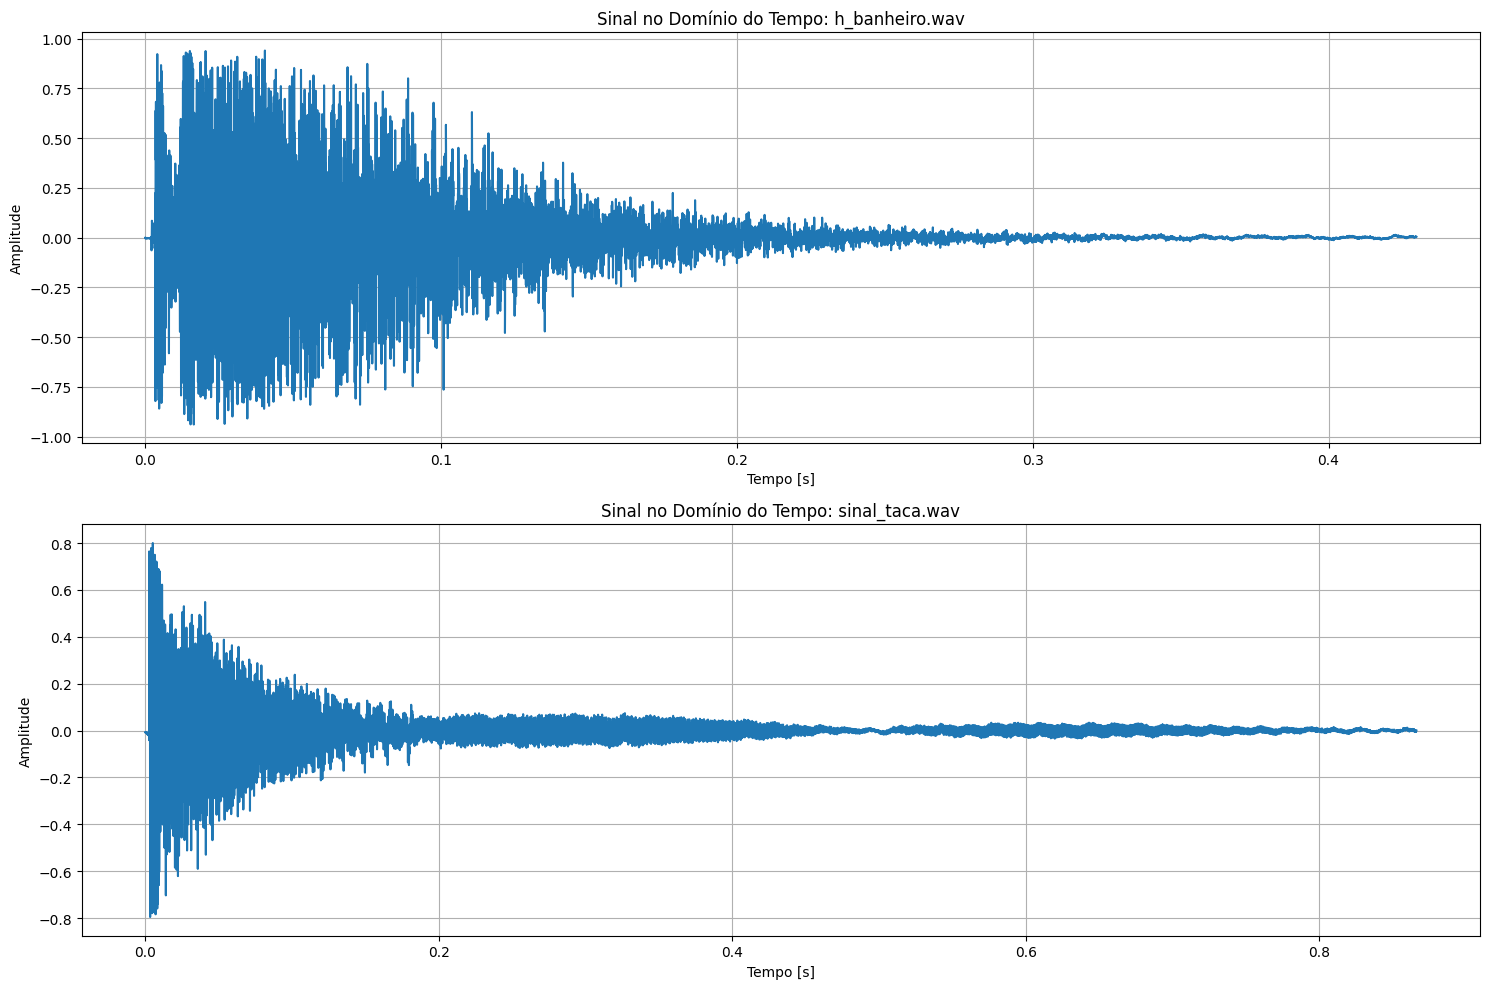

Reproduzindo h_banheiro.wav (fs=22050 Hz):


Reproduzindo sinal_taca.wav (fs=22050 Hz):


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from IPython.display import Audio, display

# (a) Ler os arquivos e gerar gráficos no domínio do tempo
files = ['/content/h_banheiro.wav', '/content/sinal_taca.wav']
audio_data = {}

plt.figure(figsize=(15, 10))

for i, file_path in enumerate(files):
    fs, data = wavfile.read(file_path)
    # Normalização
    if data.dtype == np.int16:
        data = data / 32768.0

    name = file_path.split('/')[-1]
    audio_data[name] = (data, fs)

    t_axis = np.linspace(0, len(data) / fs, len(data))

    plt.subplot(2, 1, i + 1)
    plt.plot(t_axis, data)
    plt.title(f'Sinal no Domínio do Tempo: {name}')
    plt.xlabel('Tempo [s]')
    plt.ylabel('Amplitude')
    plt.grid(True)

plt.tight_layout()
plt.show()

# (b) Código para tocar os sinais
for name, (data, fs) in audio_data.items():
    print(f"Reproduzindo {name} (fs={fs} Hz):")
    display(Audio(data, rate=fs))

**QUESTÃO 6**

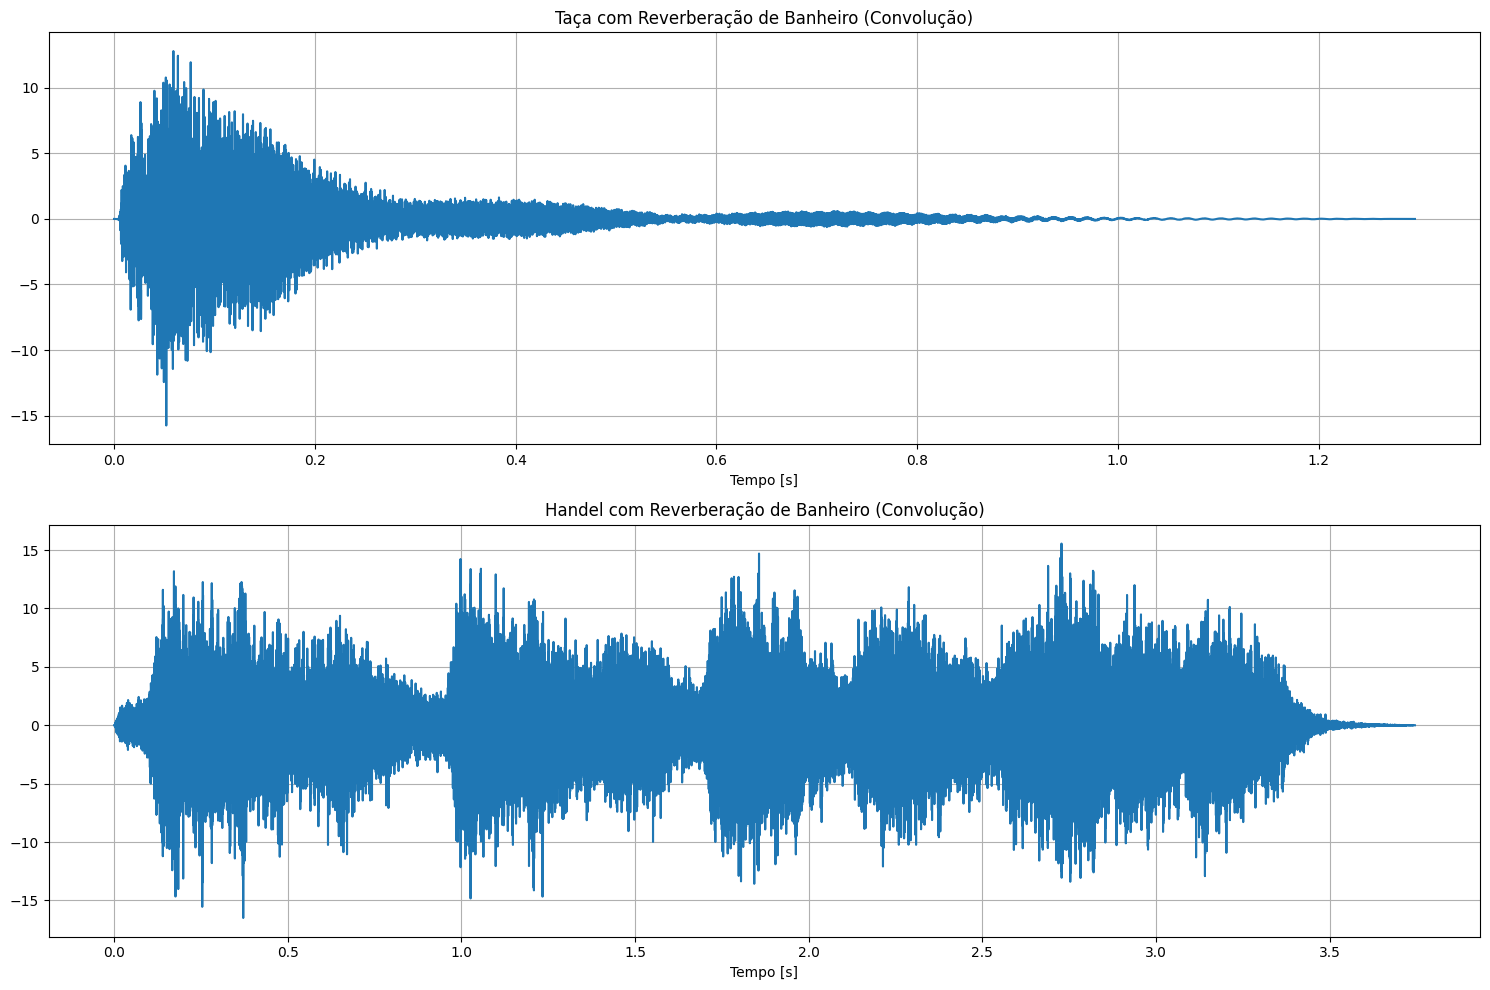

Ouvindo Taça no Banheiro:


Ouvindo Handel no Banheiro (usando fs da RI para manter o pitch do ambiente):


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from IPython.display import Audio, display

# Carregar a Resposta ao Impulso (RI)
fs_h, h_banheiro = wavfile.read('/content/h_banheiro.wav')
if h_banheiro.dtype == np.int16: h_banheiro = h_banheiro / 32768.0

# Carregar os sinais secos
fs_taca, taca = wavfile.read('/content/sinal_taca.wav')
if taca.dtype == np.int16: taca = taca / 32768.0

fs_handel, handel = wavfile.read('/content/handel.wav')
if handel.dtype == np.int16: handel = handel / 32768.0

# Como os arquivos possuem fs diferentes (22050 e 8192),
# a convolução faz sentido físico se as taxas forem compatíveis.
# Para o sinal da taça (fs=22050), a RI casa perfeitamente.

# (a) Calcular Convolução e gerar gráficos
y_taca = np.convolve(taca, h_banheiro)
y_handel = np.convolve(handel, h_banheiro) # Nota: fs_handel é 8192, h_banheiro é 22050.

plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
t_y_taca = np.linspace(0, len(y_taca) / fs_taca, len(y_taca))
plt.plot(t_y_taca, y_taca)
plt.title('Taça com Reverberação de Banheiro (Convolução)')
plt.xlabel('Tempo [s]')
plt.grid(True)

plt.subplot(2, 1, 2)
t_y_handel = np.linspace(0, len(y_handel) / fs_h, len(y_handel))
plt.plot(t_y_handel, y_handel)
plt.title('Handel com Reverberação de Banheiro (Convolução)')
plt.xlabel('Tempo [s]')
plt.grid(True)

plt.tight_layout()
plt.show()

# (b) Tocar as respostas
print("Ouvindo Taça no Banheiro:")
display(Audio(y_taca, rate=fs_taca))

print("Ouvindo Handel no Banheiro (usando fs da RI para manter o pitch do ambiente):")
display(Audio(y_handel, rate=fs_h))

### (c) Comentários sobre os resultados da Convolução

**1. Análise Temporal:**
- Observamos que o tempo de duração dos sinais resultantes é a soma da duração do sinal original com a duração da resposta ao impulso ($L = N + M - 1$).
- A forma de onda agora apresenta um 'borramento' temporal, onde a energia sonora persiste por mais tempo devido às reflexões simuladas pela cauda da RI.

**2. Avaliação Auditiva:**
- O sinal da **Taça**, que antes era seco, agora soa como se estivesse em um ambiente amplo e reflexivo. O 'brilho' metálico da taça é seguido por um decaimento espacial.
- O sinal de **Handel** ganha uma característica de 'distância' e espacialidade, mas também perde clareza (inteligibilidade), o que é comum em ambientes muito reverberantes como banheiros ou igrejas.

**3. Conclusão:**
- A convolução é a ferramenta fundamental para a **Auralização**, permitindo simular a acústica de qualquer espaço físico em um sinal de áudio digital, desde que se tenha a Resposta ao Impulso desse espaço.

### (c) Comentários sobre os resultados

**1. h_banheiro.wav (Resposta ao Impulso):**
- O gráfico mostra uma característica típica de ambientes reverberantes: um transiente inicial (o som direto) seguido por um decaimento denso e gradual (reflexões).
- Auditivamente, soa como um 'estalo' seguido pelo 'eco' característico de um banheiro (paredes lisas e reflexivas).

**2. sinal_taca.wav (Sinal da Taça):**
- Este é o sinal de entrada (excitação). No gráfico, vemos uma forma de onda que representa o impacto na taça e sua ressonância natural.
- Ao ouvi-lo, percebemos um som 'seco', ou seja, sem a influência da acústica de uma sala.

**3. Relação entre os dois:**
- Em processamento de sinais, se quisermos simular como a taça soaria dentro desse banheiro, poderíamos realizar a **convolução** entre o `sinal_taca` e a resposta ao impulso `h_banheiro`.